# Prior Shape Mismatch Study

How sensitive is the Wiener filter to the **shape** of the assumed
prior $C_\ell$, not just its overall amplitude? We fix the true sky
(Haslam-scaled) and run the mapmaker with three different priors:

1. **Haslam** $C_\ell$ (correct prior — baseline)
2. **GSM** $C_\ell$ at 45 MHz (realistic alternative from the Global Sky Model 2016)
3. **Flat** $C_\ell$ (Tikhonov regularization — no spectral information)

All at 45 MHz with the lake beam configuration (9 beams, 4 sites).

## 1. Setup

In [1]:
from pathlib import Path

import healpy as hp
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import yaml

jax.config.update("jax_enable_x64", True)

import mistsim.mapmaking as mapmaking
import mistsim.pipeline as mspipe
import mistsim.plotting as msplt

%matplotlib widget

In [2]:
# Load existing lake results — Haslam baseline
npz_path = Path("results/all-nominal-multifreq-lake.npz")
d = np.load(npz_path, allow_pickle=True)

config = yaml.safe_load(str(d["config_yaml"]))
lmax = int(d["lmax"])
nside = 128

# 45 MHz = index 5 in the freq array
fi = 5
freq_mhz = d["sim_freqs"][fi]
print(f"Frequency: {freq_mhz:.0f} MHz (index {fi})")

x_true_hp = d["x_true"][fi]
x_rec_haslam = d["x_rec"][fi]
std_alm_haslam = d["std_alm"][fi]
cl_true = hp.alm2cl(x_true_hp)

print(f"lmax = {lmax}")
print(f"Haslam baseline loaded")

Frequency: 45 MHz (index 5)
lmax = 90
Haslam baseline loaded


## 2. Prior Power Spectra

Generate the three prior $C_\ell$ curves and compare them.

In [3]:
from pygdsm import GlobalSkyModel16

# Prior 1: Haslam Cl (the true prior)
cl_prior_haslam = cl_true.copy()

# Prior 2: GSM 2016 at 45 MHz
gsm = GlobalSkyModel16(
    freq_unit="MHz", data_unit="TRJ",
    resolution="low", include_cmb=True,
)
gsm_map = gsm.generate(freq_mhz)
gsm_alm = hp.map2alm(gsm_map, lmax=lmax)
cl_prior_gsm = hp.alm2cl(gsm_alm)

# Prior 3: Flat (constant = geometric mean of true Cl)
cl_nonzero = cl_true[cl_true > 0]
cl_flat_val = np.exp(np.mean(np.log(cl_nonzero)))
cl_prior_flat = np.full(lmax + 1, cl_flat_val)

print(f"GSM nside: {hp.npix2nside(len(gsm_map))}")
print(f"Flat Cl value: {cl_flat_val:.2e}")

GSM nside: 64
Flat Cl value: 9.53e+04


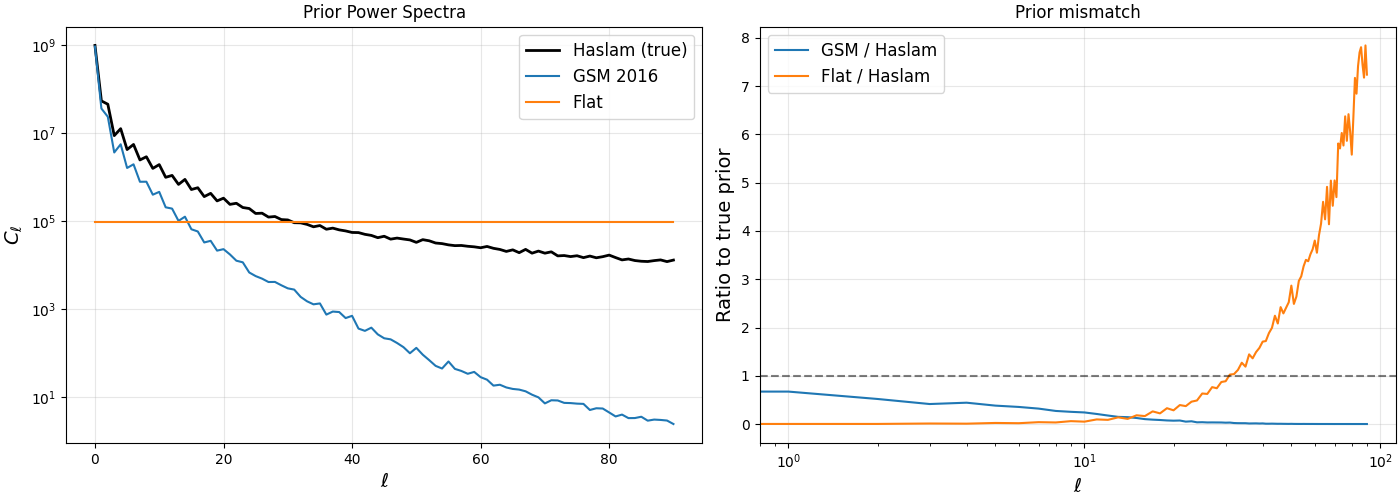

In [4]:
ell = np.arange(lmax + 1)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), constrained_layout=True,
)

ax1.semilogy(ell, cl_prior_haslam, "k-", lw=2, label="Haslam (true)")
ax1.semilogy(ell, cl_prior_gsm, "C0-", lw=1.5, label="GSM 2016")
ax1.semilogy(ell, cl_prior_flat, "C1-", lw=1.5, label="Flat")
ax1.set_xlabel(r"$\ell$", fontsize=14)
ax1.set_ylabel(r"$C_\ell$", fontsize=14)
ax1.set_title("Prior Power Spectra")
ax1.legend(fontsize=12)
ax1.grid(alpha=0.3)

# Ratio to true
valid = cl_prior_haslam > 0
ax2.semilogx(
    ell[valid], cl_prior_gsm[valid] / cl_prior_haslam[valid],
    "C0-", lw=1.5, label="GSM / Haslam",
)
ax2.semilogx(
    ell[valid], cl_prior_flat[valid] / cl_prior_haslam[valid],
    "C1-", lw=1.5, label="Flat / Haslam",
)
ax2.axhline(1, color="k", ls="--", alpha=0.5)
ax2.set_xlabel(r"$\ell$", fontsize=14)
ax2.set_ylabel("Ratio to true prior", fontsize=14)
ax2.set_title("Prior mismatch")
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

plt.show()

## 3. Rebuild Forward Model

Prepare the data for 45 MHz (same true sky, beams, noise)
and build the raw forward/adjoint operators.

In [5]:
import copy
from astropy.time import Time
import astropy.units as u
import croissant as cro

# Prepare data for one frequency
cfg = copy.deepcopy(config)
cfg["sky"]["freq_indices"] = [fi]

obs = cfg["observation"]
tstart = Time(obs["start_time"])
tend = tstart + obs["n_sidereal_days"] * u.sday
times = cro.utils.time_array(
    t_start=tstart, t_end=tend, N_times=obs["n_times"],
)
freqs = np.arange(*cfg["sky"]["freq_range"])

fdata = mspipe._prepare_freq_data(cfg, times, freqs)
print("Forward model ready")

Forward model ready


In [6]:
# Build raw (unwhitened) forward/adjoint operators
phases = fdata["phases"]
nsites = phases.shape[0]
nalm = fdata["Sdiag"].shape[1]
ba_f = fdata["beam_alms"][0]

def fwd(x):
    outs = [
        mapmaking._forward_single_freq(x, ba_f[s], phases[s])
        for s in range(nsites)
    ]
    return jnp.concatenate(outs)

xd = jnp.zeros(nalm, dtype=jnp.float64)
_tr = jax.linear_transpose(fwd, xd)

def adj(y):
    return _tr(y)[0]

Ndiag = np.asarray(fdata["Ndiag"][0])
y = np.asarray(fdata["y"][0])
noise = np.asarray(fdata["noise"][0])

print(f"nalm = {nalm}, ndata = {len(y)}, nsites = {nsites}")

nalm = 8281, ndata = 4500, nsites = 9


## 4. Solve with Each Prior

Run the CG Wiener filter with the three different $C_\ell$ priors.
The true sky and noise are identical — only $S_{\rm diag}$ changes.

In [7]:
def cl_to_sdiag(cl, lmax):
    """Convert Cl to packed Sdiag vector."""
    ells_hp, emms_hp = hp.Alm.getlm(lmax)
    ells_pos = ells_hp[emms_hp != 0]
    ells_full = np.concatenate([ells_hp, ells_pos])
    return cl[ells_full]

Sdiag_haslam = cl_to_sdiag(cl_prior_haslam, lmax)
Sdiag_gsm = cl_to_sdiag(cl_prior_gsm, lmax)
Sdiag_flat = cl_to_sdiag(cl_prior_flat, lmax)

priors = {
    "Haslam": Sdiag_haslam,
    "GSM": Sdiag_gsm,
    "Flat": Sdiag_flat,
}
print("Sdiag vectors ready")

Sdiag vectors ready


In [8]:
results_npz = Path("results/prior_mismatch_shape_45mhz.npz")

if results_npz.exists():
    print(f"Loading cached results from {results_npz}")
    cached = np.load(results_npz)
    results = {}
    for name in ["Haslam", "GSM", "Flat"]:
        results[name] = {"x_rec_hp": cached[f"x_rec_{name}"]}
        print(f"  {name}: loaded")
else:
    cg_cfg = config.get("cg", {})
    tol = cg_cfg.get("tol", 1e-10)
    maxiter = cg_cfg.get("maxiter", 2000)

    results = {}

    for name, Sd in priors.items():
        if name == "Haslam":
            results[name] = {"x_rec_hp": x_rec_haslam}
            print(f"{name}: loaded from lake npz")
            continue

        at_fwd, at_adj = mapmaking.make_atilde_fns(
            Ndiag, fwd, adj, Sd,
        )
        x_rec_hp, info = mspipe.wiener_filter_cg(
            at_fwd, at_adj, Ndiag, Sd, y, noise,
            tol=tol, maxiter=maxiter,
        )
        results[name] = {"x_rec_hp": np.asarray(x_rec_hp)}
        print(f"{name}: CG info={info}")

    # Save results
    np.savez(
        results_npz,
        **{f"x_rec_{name}": res["x_rec_hp"]
           for name, res in results.items()},
    )
    print(f"\nSaved to {results_npz}")

print("All results ready")

Loading cached results from results/prior_mismatch_shape_45mhz.npz
  Haslam: loaded
  GSM: loaded
  Flat: loaded
All results ready


## 5. Residual RMS vs $\ell_{\rm max}$

Fractional residual RMS as a function of included modes
for each prior.

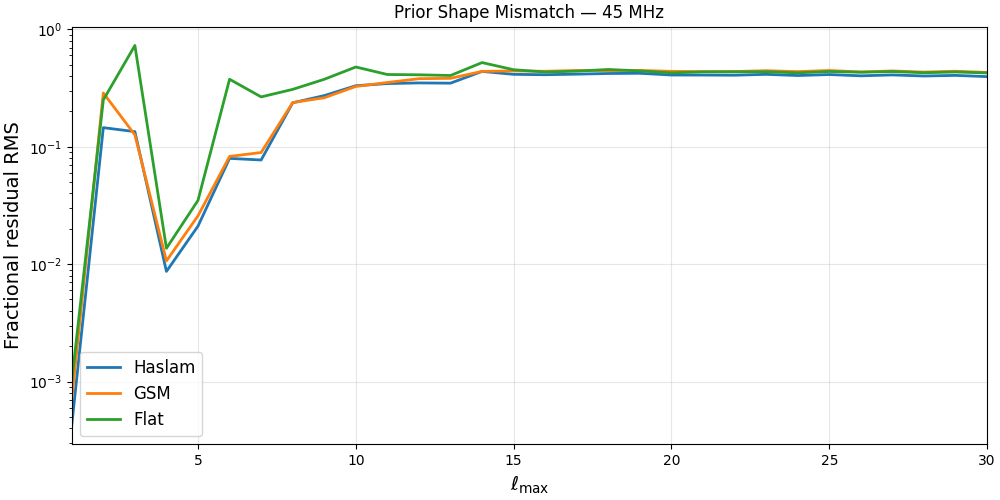

In [9]:
lmax_plot = 30

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

for name, res in results.items():
    xr = res["x_rec_hp"]
    rms_cum = np.zeros(lmax_plot + 1)
    for lcut in range(1, lmax_plot + 1):
        fl = np.zeros(lmax + 1)
        fl[:lcut + 1] = 1.0
        true_map = hp.alm2map(hp.almxfl(x_true_hp, fl), nside)
        rec_map = hp.alm2map(hp.almxfl(xr, fl), nside)
        frac_res = (true_map - rec_map) / true_map
        rms_cum[lcut] = np.sqrt(np.mean(frac_res**2))
    ax.semilogy(
        np.arange(1, lmax_plot + 1), rms_cum[1:],
        lw=2, label=name,
    )

ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=14)
ax.set_ylabel("Fractional residual RMS", fontsize=14)
ax.set_title(f"Prior Shape Mismatch — {freq_mhz:.0f} MHz")
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
ax.set_xlim(1, lmax_plot)
plt.show()

## 6. Power Spectrum and Transfer Function

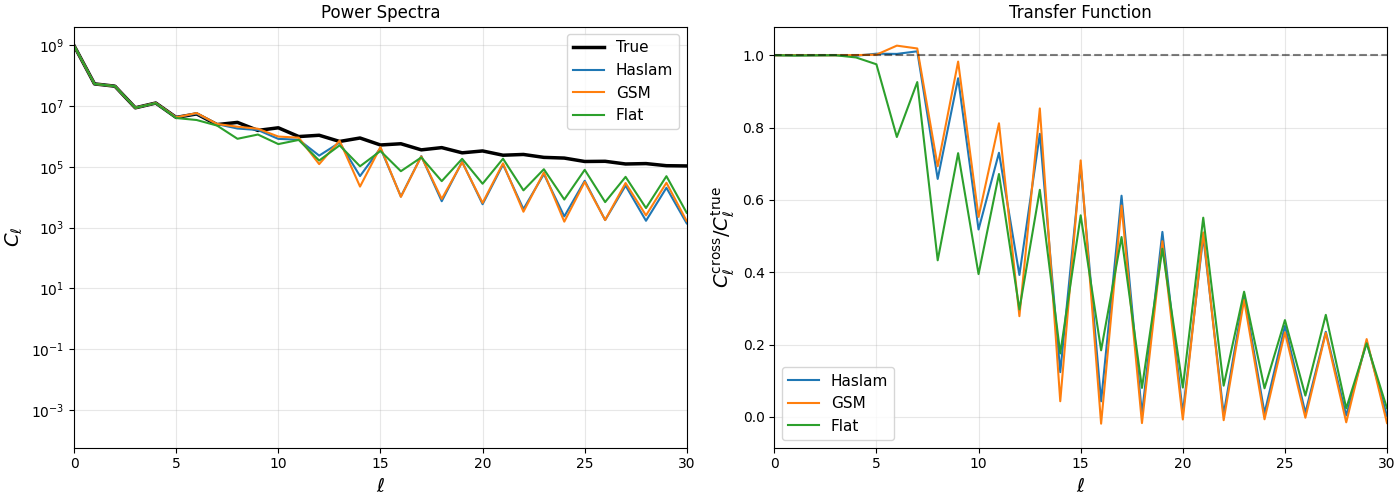

In [10]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), constrained_layout=True,
)

ax1.semilogy(ell, cl_true, "k-", lw=2.5, label="True")
for name, res in results.items():
    cl_rec = hp.alm2cl(res["x_rec_hp"])
    ax1.semilogy(ell, cl_rec, lw=1.5, label=name)
ax1.set_xlabel(r"$\ell$", fontsize=14)
ax1.set_ylabel(r"$C_\ell$", fontsize=14)
ax1.set_title("Power Spectra")
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 30)

for name, res in results.items():
    cl_cross = hp.alm2cl(x_true_hp, res["x_rec_hp"])
    tf = np.zeros_like(cl_true)
    valid = cl_true > 0
    tf[valid] = cl_cross[valid] / cl_true[valid]
    ax2.plot(ell, tf, lw=1.5, label=name)
ax2.axhline(1, color="k", ls="--", alpha=0.5)
ax2.set_xlabel(r"$\ell$", fontsize=14)
ax2.set_ylabel(
    r"$C_\ell^{\rm cross}/C_\ell^{\rm true}$", fontsize=14,
)
ax2.set_title("Transfer Function")
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)
ax2.set_xlim(0, 30)

plt.show()

## 7. Map Comparison

True map vs recovered maps for each prior,
low-pass filtered at $\ell \le 10$, Galactic coordinates.

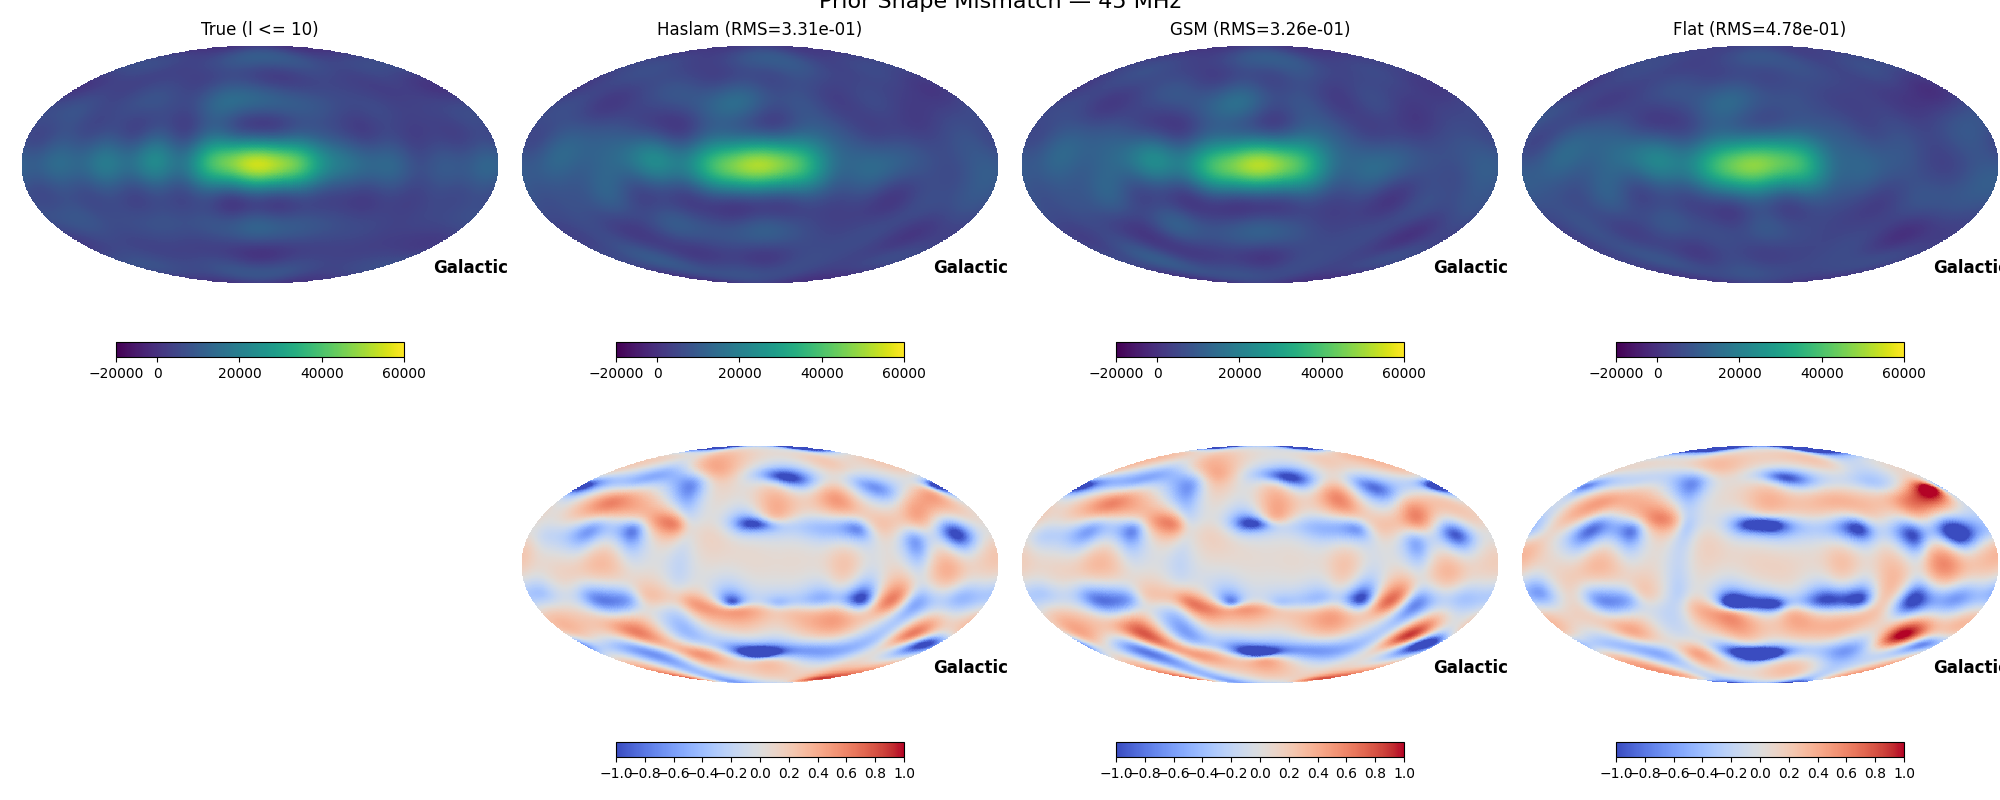

In [11]:
plot_lmax_map = 10

# Compute RMS for each prior
rms_per_prior = {}
for name, res in results.items():
    fl = np.zeros(lmax + 1)
    fl[:plot_lmax_map + 1] = 1.0
    true_map = hp.alm2map(hp.almxfl(x_true_hp, fl), nside)
    rec_map = hp.alm2map(hp.almxfl(res["x_rec_hp"], fl), nside)
    frac_res = (true_map - rec_map) / true_map
    rms_per_prior[name] = np.sqrt(np.mean(frac_res**2))

x_recs = [res["x_rec_hp"] for res in results.values()]
labels = [
    f"{name} (RMS={rms_per_prior[name]:.2e})"
    for name in results.keys()
]

fig = msplt.plot_comparison_grid(
    x_true_hp, x_recs, labels,
    lmax=lmax, plot_lmax=plot_lmax_map, nside=nside,
    plot_galactic=True, ratio=True, frac_range=1.0,
    orientation="horizontal",
)
fig.suptitle(
    f"Prior Shape Mismatch — {freq_mhz:.0f} MHz",
    fontsize=16, y=1.01,
)
plt.show()

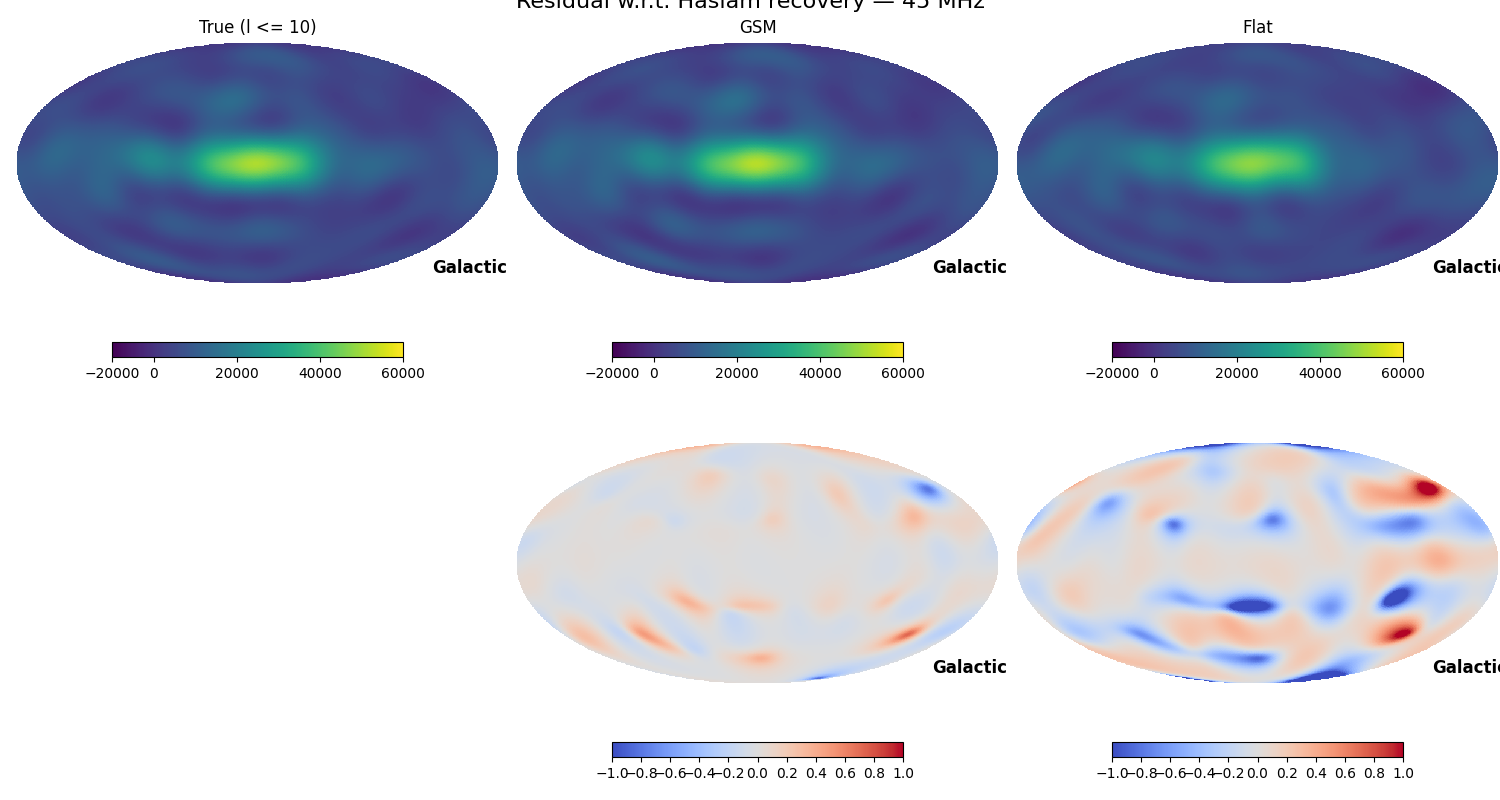

In [15]:
# Residual w.r.t. the Haslam (correct prior) recovery
x_rec_ref = results["Haslam"]["x_rec_hp"]
x_recs_diff = [
    results[name]["x_rec_hp"] for name in ["GSM", "Flat"]
]
labels_diff = ["GSM", "Flat"]

fig = msplt.plot_comparison_grid(
    x_rec_ref, x_recs_diff, labels_diff,
    lmax=lmax, plot_lmax=plot_lmax_map, nside=nside,
    plot_galactic=True, ratio=True, frac_range=1.,
    orientation="horizontal",
)
fig.suptitle(
    f"Residual w.r.t. Haslam recovery — {freq_mhz:.0f} MHz",
    fontsize=16, y=1.01,
)
plt.show()

## 8. $a_{\ell m}$ Comparison

True vs recovered harmonic coefficients for each prior.
Error bars shown for Haslam (correct prior) only.

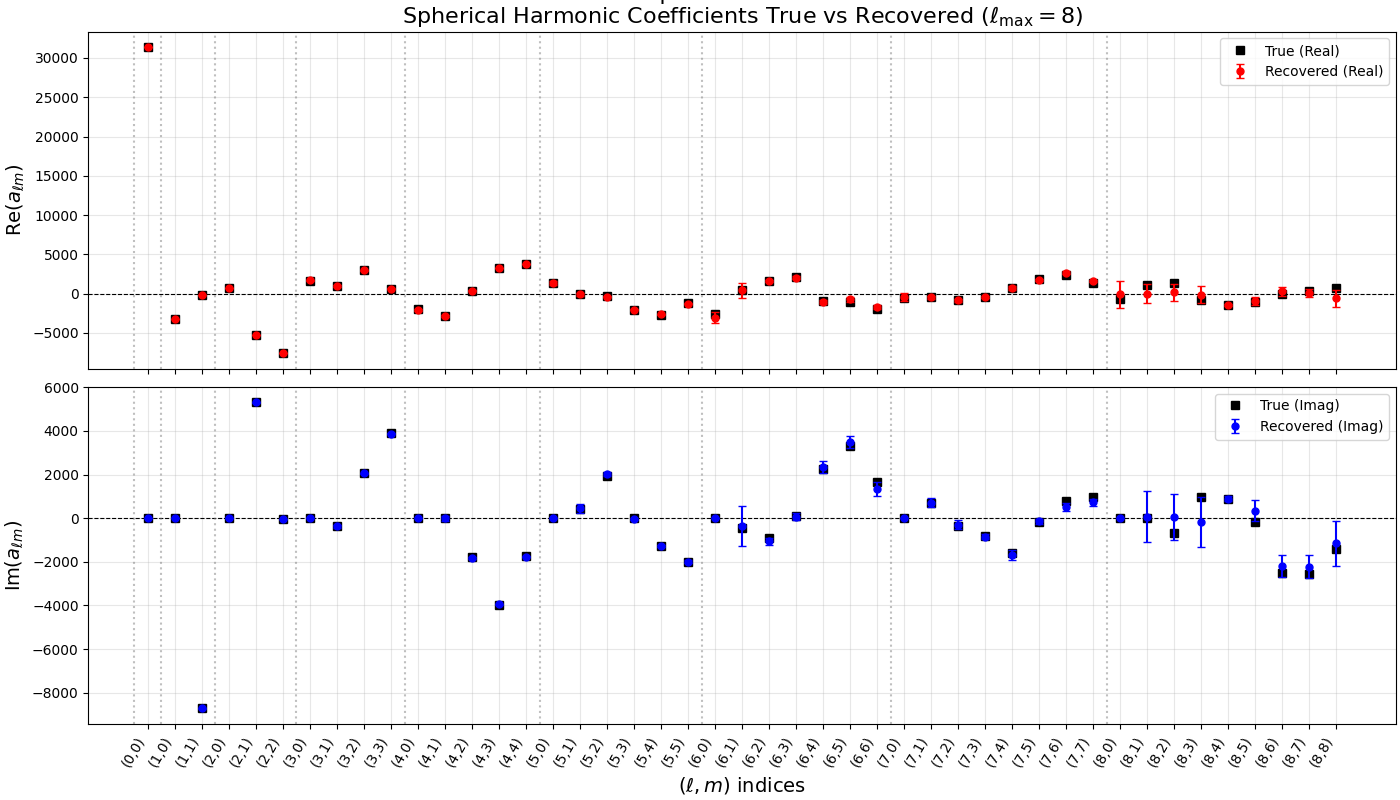

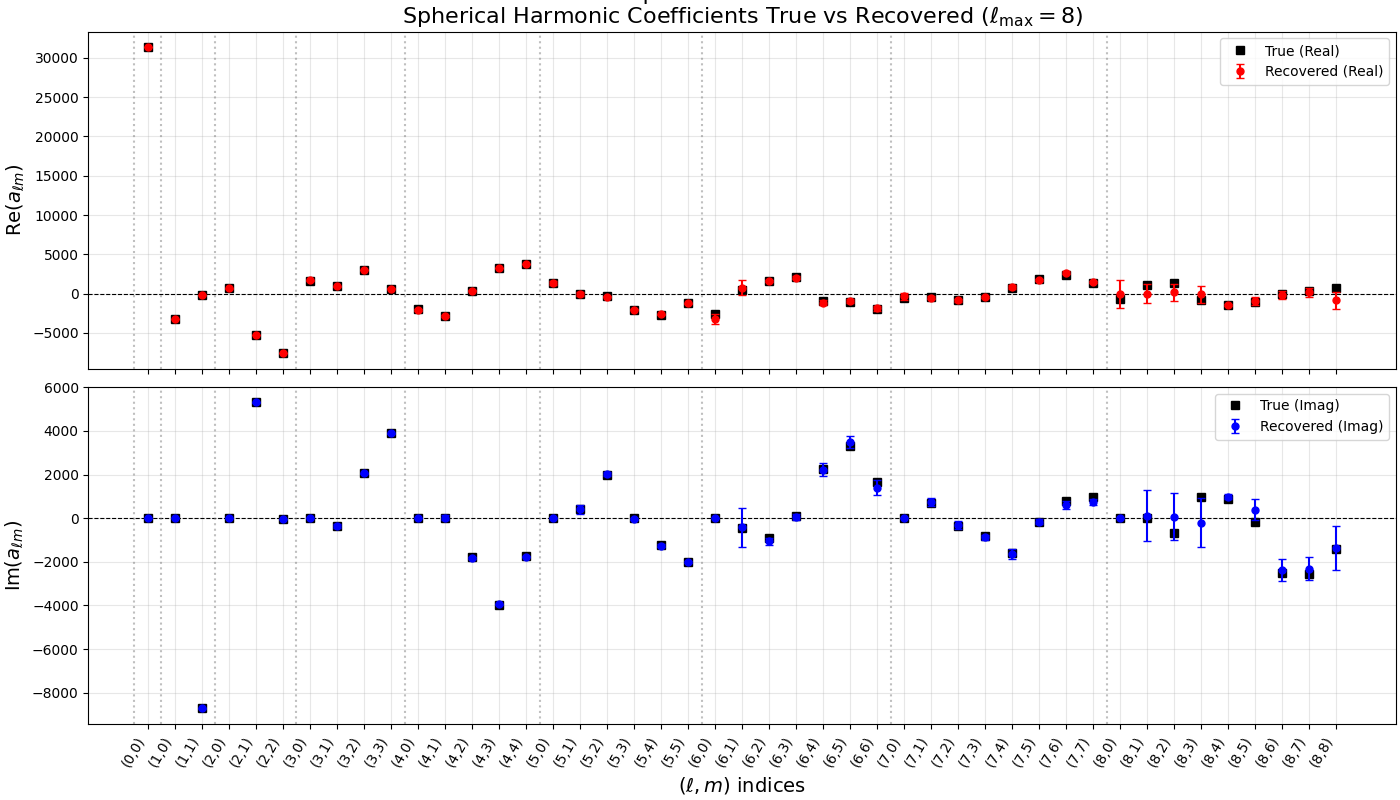

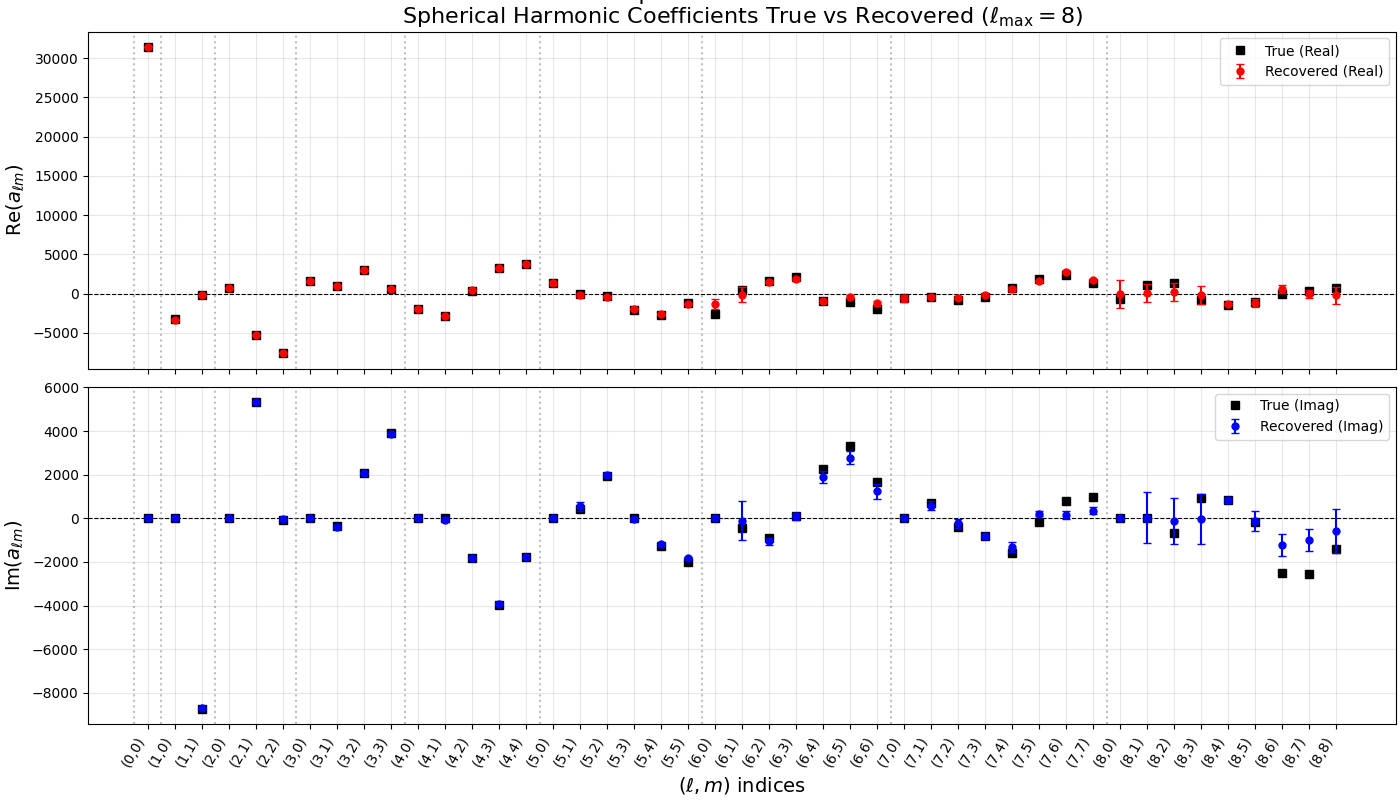

In [12]:
for name, res in results.items():
    # Use Haslam std_alm as reference error bars for all
    fig = msplt.plot_alm_comparison(
        x_true_hp, res["x_rec_hp"],
        std_alm_haslam, lmax, lmax_plot=8,
    )
    fig.suptitle(
        f"{name} prior — {freq_mhz:.0f} MHz",
        fontsize=16, y=1.02,
    )
    plt.show()